# **COMP-603 Programming for Data Science**

## **Final Project**

Group-1 Members:
* Mansi Patel
* Amankumar Desai
* Varinderpal Singh


Submitted To: Abu Hena Al Muktadir

Submission Date: April 23, 2026

Program: Artificial Intelligence and Data Analytics Post-Graduate Certificate

Institution: Saskatchewan Polytechnic, Regina Campus

## Introduction

The COVID-19 pandemic created significant disruption across businesses in Canada and around the world. Changes in consumer purchasing behavior, lockdown restrictions, business closures, and the rapid growth of e-commerce all had a direct impact on parcel delivery demand. While some companies experienced declining shipment volumes, others saw strong growth due to increased reliance on online shopping and home delivery services.

This project analyzes the impact of COVID-19 on **ABC Company’s parcel delivery business** using the provided dataset **COVID_Parcel_Business.csv**. The dataset contains customer shipment records organized by customer ID, year, week number, and parcel volume. By using Python for data analysis and visualization, this project transforms raw operational data into meaningful business insights.

The main objective of this analysis is to answer the core business question:

**How did the COVID-19 pandemic impact ABC Company’s parcel business?**

The analysis follows a complete analytical process that includes:

1. Data loading and inspection  
2. Data cleaning and preparation  
3. Exploratory data analysis  
4. Time-series trend analysis  
5. Customer segmentation analysis  
6. Revenue and business impact estimation  
7. Executive-level visualization and insights  

To estimate business performance, parcel revenue is calculated using the pricing and discount assumptions. Customer growth categories are determined by comparing shipment behavior before COVID and during the COVID observation period.

The final outcome of this project is to provide a clear, data-driven explanation of how COVID-19 affected ABC Company’s parcel business, while presenting insights in an executive-friendly format that supports strategic decision-making.

## Definition of COVID Periods

To analyze the impact of COVID-19 on parcel volumes, the timeline is divided into pre-COVID and COVID observation periods based on both data trends and real-world events.

- **Pre-COVID Period:** Weeks 1 to 12 of 2020  
  This period reflects normal business conditions prior to significant pandemic-related disruptions.

- **COVID Observation Period:** Week 13 onward in 2020  
  This period captures the impact of the pandemic following the initial disruption phase, where changes in customer behavior and business activity became more evident.

The transition point is supported by the COVID-19 emergency declaration in Canada around Week 12, with observable shifts in parcel volumes occurring shortly after.

This classification allows for a consistent comparison between pre-pandemic and pandemic conditions, and is used throughout the analysis to evaluate changes in volume, customer behavior, and growth trends.

## Importing Required Libraries

This step imports the Python libraries required to perform data analysis, numerical computation, and data visualization for the project. These libraries provide the tools needed to clean the dataset, manipulate data structures, generate charts, and format outputs efficiently.

* `pandas` is imported as `pd` and is used for loading the CSV dataset, handling tabular data, performing filtering, grouping, aggregation, and other data transformation tasks.

* `numpy` is imported as `np` and is used for numerical operations, mathematical calculations, array processing, and supporting statistical computations throughout the analysis.

* `matplotlib.pyplot` is imported as `plt` and is used to create visualizations such as line charts, bar charts, and other graphical outputs required for presenting trends and business insights.

* `matplotlib.ticker` is imported as `mticker` and is used to customize chart axis labels, scales, and formatting, especially for presenting large numbers, percentages, and currency values in a readable format.

* `matplotlib.patches` is imported as `mpatches` and is used to create custom legends, shapes, and additional graphical elements that improve chart presentation and interpretation.

* The `warnings` library is used to suppress unnecessary warning messages during notebook execution by applying `warnings.filterwarnings('ignore')`. This helps maintain a clean and professional output while running the analysis.

Overall, this step prepares the notebook environment with all essential tools required for data processing, visualization, and business analysis in the project.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches

## Loading the Dataset

In this step, the file **COVID_Parcel_Business.csv** is loaded into a Pandas DataFrame named `df` using `pd.read_csv()`. This converts the raw CSV file into a structured table for analysis.

The command `df.head(10)` displays the first 10 rows of the dataset to verify that the file has loaded correctly and to preview the column structure and sample records.

This step helps confirm that the dataset is ready for further cleaning, exploration, and analysis.

In [2]:
df = pd.read_csv('COVID_Parcel_Business.csv')
df.head(10)

,FakeCustomerID,THE_YEAR,THE_WEEK,VOLUME
0,718117,2021,1,8
1,718117,2020,7,257
2,718117,2019,39,141
3,718117,2018,1,14
4,718117,2021,2,192
5,718117,2018,2,18
6,718117,2020,8,232
7,718117,2020,10,229
8,718117,2020,2,251
9,718117,2019,5,93


## Dataset Dimensions

The command `df.shape` returns the total number of rows and columns in the dataset. Displaying the dataset shape provides a quick overview of the size of the data being analyzed.

This is useful for understanding the volume of records available and confirming that the dataset has been loaded completely before proceeding with further analysis.

In [3]:
print(f"Dataset shape: {df.shape}")

Dataset shape: (190719, 4)


## Dataset Information

The command `df.info()` provides a summary of the dataset structure, including column names, number of non-null values, data types, and memory usage.

This output helps identify missing values, verify whether columns are stored in the correct format, and better understand the overall structure of the dataset before performing data cleaning and analysis.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 190719 entries, 0 to 190718
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype
---  ------          --------------   -----
 0   FakeCustomerID  190719 non-null  int64
 1   THE_YEAR        190719 non-null  int64
 2   THE_WEEK        190719 non-null  int64
 3   VOLUME          190719 non-null  int64
dtypes: int64(4)
memory usage: 5.8 MB


## Descriptive Statistics

The command `df.describe()` generates summary statistics for numerical columns in the dataset, such as count, mean, standard deviation, minimum value, maximum value, and quartiles.

This provides an overview of data distribution, central tendency, and variation, helping identify unusual values and understand shipment volume patterns before deeper analysis.

In [5]:
df.describe()

,FakeCustomerID,THE_YEAR,THE_WEEK,VOLUME
count,190719.000000,190719.000000,190719.000000,190719.000000
mean,541440.234963,2019.395220,25.676377,1174.911519
std,264861.365663,1.068845,14.722539,11586.730666
min,100771.000000,2018.000000,1.000000,1.000000
25%,308930.000000,2018.000000,13.000000,25.000000
50%,529707.000000,2019.000000,25.000000,58.000000
75%,778800.000000,2020.000000,38.000000,162.000000
max,999362.000000,2021.000000,53.000000,640590.000000


## Dataset Overview

This code displays key summary metrics of the dataset to provide a high-level understanding of the available data.

The output includes:

- Total number of records in the dataset  
- Number of unique customers  
- Years included in the analysis  
- Range of week numbers available per year  
- Total parcel volume shipped  
- Average parcel volume per record  
- Maximum parcel volume in a single record  

These metrics help summarize the scale, time coverage, and shipment activity of the dataset before detailed analysis begins.

In [6]:
print("Dataset Overview")
print(f"Total records      : {len(df):,}")
print(f"Unique customers   : {df['FakeCustomerID'].nunique():,}")
print(f"Years covered      : {sorted(df['THE_YEAR'].unique())}")
print(f"Weeks per year     : 1 – {df['THE_WEEK'].max()}")
print(f"Total parcels      : {df['VOLUME'].sum():,.0f}")
print(f"Avg parcels/record : {df['VOLUME'].mean():,.1f}")
print(f"Max parcels/record : {df['VOLUME'].max():,}")

Dataset Overview
Total records      : 190,719
Unique customers   : 1,061
Years covered      : [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021)]
Weeks per year     : 1 – 53
Total parcels      : 224,077,950
Avg parcels/record : 1,174.9
Max parcels/record : 640,590


## Missing Values Check

The command `df.isnull().sum()` calculates the number of missing values in each column of the dataset.

This helps identify incomplete records or data quality issues that may need to be addressed before performing further analysis.

In [7]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
FakeCustomerID    0
THE_YEAR          0
THE_WEEK          0
VOLUME            0
dtype: int64


## Weeks Reported by Year

The dataset is grouped by `THE_YEAR` to count the number of unique weeks reported for each year.

The output shows how many weeks of data are available annually and flags years with fewer than 52 weeks as partial data. This helps verify data completeness and time coverage before trend analysis.

In [8]:
weeks_per_year = df.groupby('THE_YEAR')['THE_WEEK'].nunique()

for year, weeks in weeks_per_year.items():
    note = " (partial data)" if weeks < 52 else ""
    print(f"{year}: {weeks} weeks reported{note}")

2018: 53 weeks reported
2019: 53 weeks reported
2020: 53 weeks reported
2021: 39 weeks reported (partial data)


## **How did the COVID-19 pandemic impact ABC Company’s parcel business?**

## Parcels Shipped by Year

This code groups the dataset by `THE_YEAR` and calculates the total parcel volume for each year using the `sum()` function on the `VOLUME` column.

The results are then formatted for readability and displayed to compare annual shipment volumes across the years in the dataset.

This summary helps identify year-over-year changes in parcel demand and supports analysis of how COVID-19 influenced shipping activity.

In [9]:
print("Parcels Shipped by Year")
yearly = df.groupby('THE_YEAR')['VOLUME'].sum()
print(yearly.apply(lambda x: f"{x:,.0f}"))

Parcels Shipped by Year
THE_YEAR
2018    49,099,478
2019    52,823,114
2020    73,475,690
2021    48,679,668
Name: VOLUME, dtype: object


## Year-over-Year Growth Rate

The percentage change in total parcel volume between 2019 and 2020 is calculated using annual shipment totals.

This measures the growth or decline in business activity from one year to the next and helps quantify the overall impact of COVID-19 on parcel demand.

In [10]:
growth_pct = ((yearly[2020] - yearly[2019]) / yearly[2019]) * 100
print(f"Year-over-Year Growth (2019 - 2020): {growth_pct:.2f}%")

Year-over-Year Growth (2019 - 2020): 39.10%


## Annual Parcel Volume Visualization

A bar chart is created to compare the total parcels shipped by year using the aggregated yearly shipment data. Parcel volumes are converted into millions to improve readability and presentation.

The year **2020** is highlighted in a different color to emphasize the period impacted by COVID-19. Data labels are added above each bar to display annual shipment totals, while the year-over-year growth percentage from 2019 to 2020 is also shown.

An additional note is included for **2021** to indicate that only 39 weeks of data are reported, ensuring accurate interpretation of lower totals.

This visualization helps compare annual business performance and clearly illustrates the impact of COVID-19 on parcel shipment volumes.

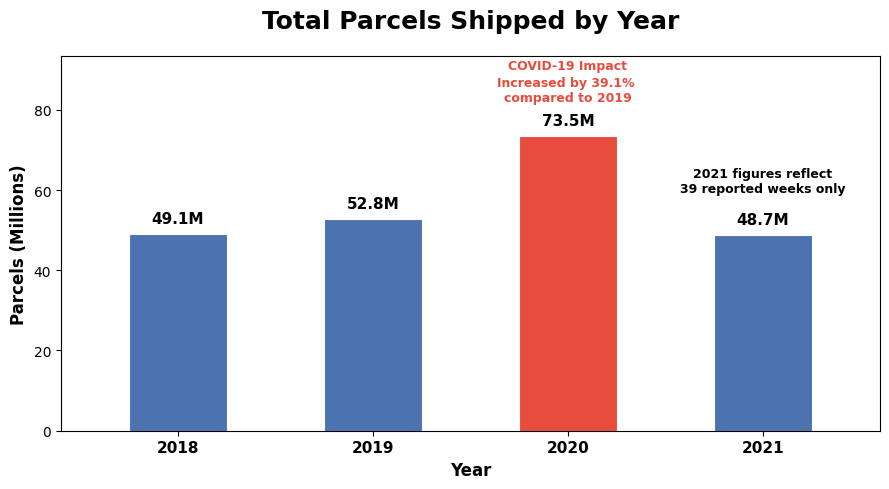

In [11]:
growth_2020 = ((yearly[2020] - yearly[2019]) / yearly[2019]) * 100

fig, ax = plt.subplots(figsize=(9, 5))

colors = ['#4c72b0', '#4c72b0', '#e74c3c', '#4c72b0']

bars = ax.bar(
    yearly.index,
    yearly.values / 1e6,
    color=colors,
    edgecolor='white',
    linewidth=0.8,
    width=0.5
)

ax.set_title(
    'Total Parcels Shipped by Year',
    fontsize=18,
    fontweight='bold',
    pad=20
)

ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Parcels (Millions)', fontsize=12, fontweight='bold')

for bar, val in zip(bars, yearly.values):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 2,
        f'{val/1e6:.1f}M',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

for bar, year in zip(bars, yearly.index):
    if year == 2020:
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 8,
            f"Increased by {growth_2020:.1f}% \ncompared to 2019",
            ha='center',
            va='bottom',
            fontsize=9,
            fontweight='bold',
            color='#e74c3c'
        )

ax.text(
    2020,
    yearly[2020]/1e6 + 16,
    'COVID-19 Impact',
    ha='center',
    va='bottom',
    fontsize=9,
    fontweight='bold',
    color='#e74c3c'
)

ax.text(
    2021,
    yearly[2021]/1e6 + 10,
    '2021 figures reflect\n39 reported weeks only',
    ha='center',
    va='bottom',
    fontsize=9,
    fontweight='bold',
    color='black'
)

ax.set_ylim(0, max(yearly.values / 1e6) + 20)
ax.set_xlim(min(yearly.index) - 0.6, max(yearly.index) + 0.6)
ax.set_xticks(yearly.index)
ax.set_xticklabels(yearly.index, fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('fig_annual_volume.png', dpi=150, bbox_inches='tight')
plt.show()

## **When were customer volumes first impacted by COVID-19?**

## Industry Standard Growth Rate (ISGR)

Parcel volumes for **Weeks 1 to 12** in 2019 and 2020 are calculated to measure business growth before the COVID-19 disruption. This pre-COVID period serves as a baseline for normal year-over-year performance.

The **Industry Standard Growth Rate (ISGR)** is computed as the percentage change between pre-COVID 2019 and pre-COVID 2020 parcel volumes. This benchmark helps distinguish normal business growth from changes specifically driven by the COVID-19 pandemic.

The ISGR is then used to classify customer performance during the COVID period as follows:

- **High Growth Customers:** Growth above ISGR  
- **Stable Customers:** Growth between 0% and ISGR  
- **Declining Customers:** Negative growth  
- **New Customers:** No prior activity before COVID, but active during COVID  
- **Lost Customers:** Active before COVID, but no activity during COVID  

This classification enables a clearer understanding of how different customers responded to the pandemic.

In [12]:
pre_wks = 12

vol_pre_2019 = df[(df['THE_YEAR'] == 2019) & (df['THE_WEEK'] <= pre_wks)]['VOLUME'].sum()
vol_pre_2020 = df[(df['THE_YEAR'] == 2020) & (df['THE_WEEK'] <= pre_wks)]['VOLUME'].sum()

ISGR = ((vol_pre_2020 - vol_pre_2019) / vol_pre_2019) * 100 if vol_pre_2019 != 0 else None
ISGR_decimal  = ISGR / 100

print(f"Pre-COVID 2019 Volume (Week 1–12) : {vol_pre_2019:>15,.0f} parcels")
print(f"Pre-COVID 2020 Volume (Week 1–12) : {vol_pre_2020:>15,.0f} parcels")
print(f"Industry Standard Growth Rate     : {ISGR:>14.2f}%")
print("\nInterpretation:")
print(f"Before COVID hit, volumes were already growing at {ISGR:.1f}% year-over-year. This baseline is used to distinguish normal business growth from COVID-driven changes in customer behavior.")
print("\nClassification Rules Based on ISGR:")
print(f"High Growth Customers   : > {ISGR:.1f}% during COVID period")
print(f"Stable Customers        : 0% to {ISGR:.1f}% during COVID period")
print(f"Declining Customers     : < 0% during COVID period")
print(f"New Customers           : 0 parcels in 2019 and pre-COVID 2020, but active during COVID period")
print(f"Lost Customers          : Had activity in 2019/pre-COVID but 0 parcels during COVID period")

Pre-COVID 2019 Volume (Week 1–12) :      10,576,987 parcels
Pre-COVID 2020 Volume (Week 1–12) :      10,707,239 parcels
Industry Standard Growth Rate     :           1.23%

Interpretation:
Before COVID hit, volumes were already growing at 1.2% year-over-year. This baseline is used to distinguish normal business growth from COVID-driven changes in customer behavior.

Classification Rules Based on ISGR:
High Growth Customers   : > 1.2% during COVID period
Stable Customers        : 0% to 1.2% during COVID period
Declining Customers     : < 0% during COVID period
New Customers           : 0 parcels in 2019 and pre-COVID 2020, but active during COVID period
Lost Customers          : Had activity in 2019/pre-COVID but 0 parcels during COVID period


## Weekly Year-over-Year Growth Comparison

Weekly parcel volumes for 2019 and 2020 are grouped by year and week, then arranged side by side for direct comparison.

A **Year-over-Year (YoY) Growth** percentage is calculated for each week by comparing 2020 volumes against the corresponding week in 2019.

The output displays weekly shipment totals and growth rates, helping identify when parcel volumes first began to change significantly during the early stages of the COVID-19 period.

In [13]:
weekly = df[df['THE_YEAR'].isin([2019, 2020])].groupby(['THE_YEAR','THE_WEEK'])['VOLUME'].sum().unstack(0)
weekly.columns = ['2019', '2020']
weekly['YoY_Growth'] = (weekly['2020'] - weekly['2019']) / weekly['2019'] * 100
weekly.head()

,2019,2020,YoY_Growth
THE_WEEK,,,
1,814361,554951,-31.854423
2,1048800,1078417,2.823894
3,1073634,1008084,-6.105433
4,937502,934713,-0.297493
5,870849,938521,7.770808


## **What events within the COVID timeline may have contributed to the change?**

## Weekly Parcel Volume Trend: 2019 vs 2020

A line chart is created to compare weekly parcel shipment volumes between **2019** and **2020**. Volumes are displayed in millions to improve readability.

The chart includes key COVID-related timeline markers, such as the **Canada emergency declaration (Week 12)** and the beginning of the defined **COVID observation period (Week 13)**. It also highlights the **holiday peak season (Week 45)**, an important period for parcel delivery demand.

The shaded region represents the COVID period, while an additional highlight indicates the peak season, allowing clear visual comparison of shipment trends across different phases of the year.

This visualization helps identify when parcel volumes began to shift, how demand changed during the pandemic, and how peak season activity in 2020 compares with the previous year.

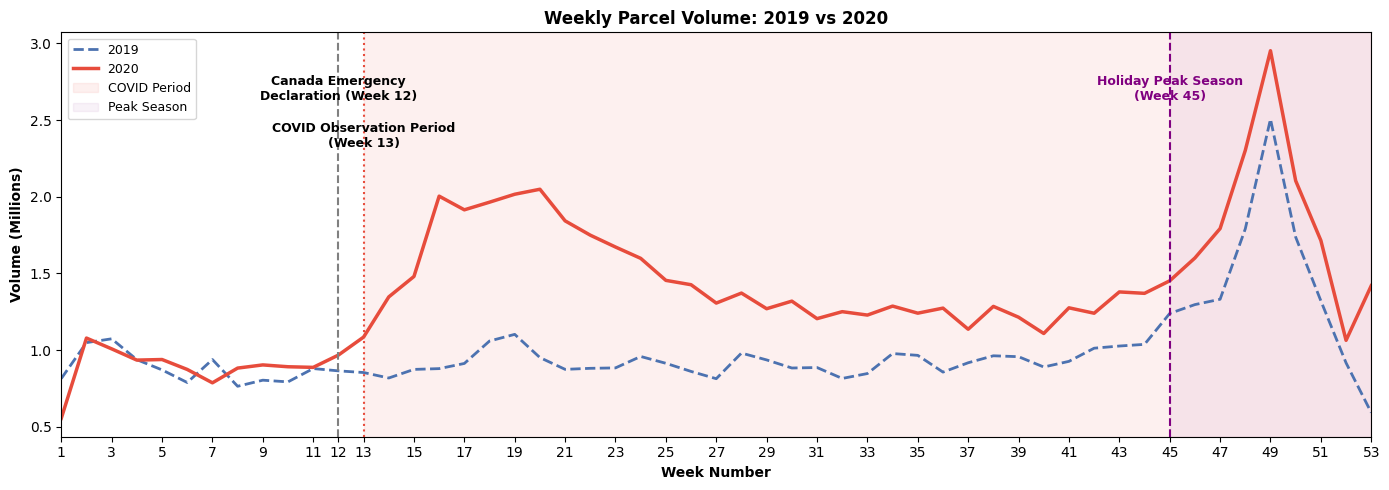

In [14]:
covid_start_week = 13
holiday_week = 45

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(weekly.index, weekly['2019'] / 1e6, label='2019',
        color='#4c72b0', linewidth=2, linestyle='--')

ax.plot(weekly.index, weekly['2020'] / 1e6, label='2020',
        color='#e74c3c', linewidth=2.5)

ax.axvspan(covid_start_week, 53,
           alpha=0.08, color='#e74c3c',
           label='COVID Period')

ax.axvline(x=12, color='grey', linestyle='--', linewidth=1.5)

ax.axvline(x=covid_start_week,
           color='#e74c3c', linestyle=':', linewidth=1.5)

ax.axvline(x=holiday_week,
           color='purple', linestyle='--', linewidth=1.5)

ax.text(12, ax.get_ylim()[1]*0.85,
        'Canada Emergency\nDeclaration (Week 12)',
        ha='center', va='bottom',
        fontsize=9, fontweight='bold')

ax.text(covid_start_week, ax.get_ylim()[1]*0.75,
        'COVID Observation Period\n(Week 13)',
        ha='center', va='bottom',
        fontsize=9, fontweight='bold')

ax.text(holiday_week, ax.get_ylim()[1]*0.85,
        'Holiday Peak Season\n(Week 45)',
        ha='center', va='bottom',
        fontsize=9, fontweight='bold', color='purple')

ax.axvspan(holiday_week, 53,
           alpha=0.05, color='purple',
           label='Peak Season')

ax.set_title('Weekly Parcel Volume: 2019 vs 2020', fontweight='bold')
ax.set_xlabel('Week Number', fontweight='bold')
ax.set_ylabel('Volume (Millions)', fontweight='bold')

ax.legend(loc='upper left', fontsize=9)
ax.set_xlim(1, 53)

base_ticks = list(range(1, 54, 2))
event_ticks = [12, covid_start_week, holiday_week]
all_ticks = sorted(set(base_ticks + event_ticks))
ax.set_xticks(all_ticks)

plt.tight_layout()
plt.savefig('fig_weekly_volume_2019_2020.png', dpi=150, bbox_inches='tight')
plt.show()

## **How did COVID-19 impact peak season in 2020?**

## Peak Season Volume Comparison

Parcel volumes are calculated for the peak season period from **Week 45 to Week 53** for both 2019 and 2020.

The percentage change between the two years is then measured to evaluate how COVID-19 influenced shipping demand during the busiest season of the year.

This comparison helps determine whether peak season volumes increased or decreased during the pandemic.

In [15]:
peak_start = 45
peak_end   = 53

peak_2019 = df[
    (df['THE_YEAR'] == 2019) &
    (df['THE_WEEK'] >= peak_start) &
    (df['THE_WEEK'] <= peak_end)
]['VOLUME'].sum()

peak_2020 = df[
    (df['THE_YEAR'] == 2020) &
    (df['THE_WEEK'] >= peak_start) &
    (df['THE_WEEK'] <= peak_end)
]['VOLUME'].sum()

pct_change_peak = ((peak_2020 - peak_2019) / peak_2019) * 100

print(f"Peak Season 2019 Volume : {peak_2019:,}")
print(f"Peak Season 2020 Volume : {peak_2020:,}")
print(f"YoY Change              : +{pct_change_peak:.1f}%")

Peak Season 2019 Volume : 12,731,239
Peak Season 2020 Volume : 16,402,470
YoY Change              : +28.8%


## Peak Season Comparison Visualization

A bar chart is used to present the peak season totals for 2019 and 2020, with clear value labels for each year. An annotation is included to highlight the percentage change between the two periods.

This chart provides a focused visual comparison of peak season performance, making it easier to interpret the magnitude of change during the COVID-19 period.

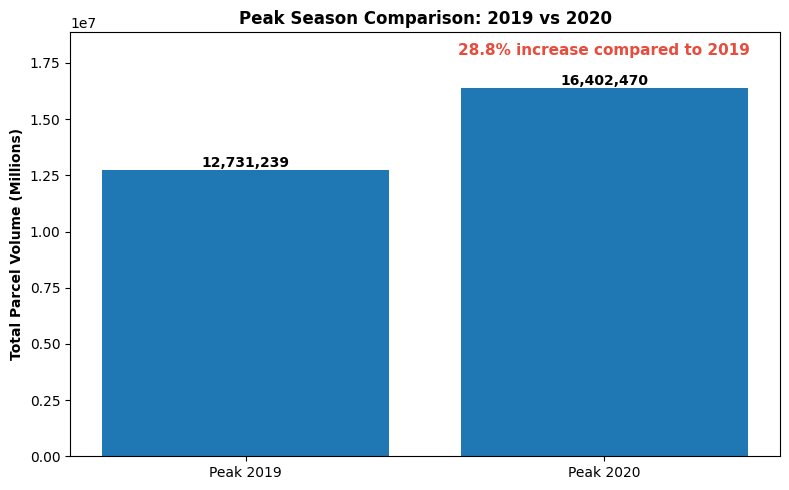

In [16]:
labels = ['Peak 2019', 'Peak 2020']
values = [peak_2019, peak_2020]

fig, ax = plt.subplots(figsize=(8,5))
bars = ax.bar(labels, values)

for bar in bars:
    y = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        y,
        f'{int(y):,}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

ax.text(
    bars[1].get_x() + bars[1].get_width()/2,
    bars[1].get_height() * 1.08,
    f'{pct_change_peak:.1f}% increase compared to 2019',
    ha='center',
    va='bottom',
    fontsize=11,
    fontweight='bold',
    color='#e74c3c'
)

ax.set_ylim(0, max(values) * 1.15)

ax.set_title('Peak Season Comparison: 2019 vs 2020', fontweight='bold')
ax.set_ylabel('Total Parcel Volume (Millions)', fontweight='bold')

plt.tight_layout()
plt.savefig('fig_peak_season.png', dpi=150, bbox_inches='tight')
plt.show()

## Pricing and Discount Structure

The base price per parcel is defined and adjusted for each customer group using predefined discount rates. A pricing dictionary is created to calculate the effective price per parcel after applying the respective discounts.

Customer groups are also organized in a specific order for consistent analysis and visualization, and corresponding color mappings are defined for use in charts.

The discount structure used in this analysis is summarized below:

| Customer Group | Discount (%) |
|----------------|-------------|
| Enterprise     | 22%         |
| Large          | 17%         |
| Medium         | 10%         |
| Small          | 4%          |

The output displays the final price per parcel for each customer group along with the applied discount percentage, providing a clear reference for revenue calculations in later analysis.

In [17]:
BASE_PRICE   = 22.00
DISCOUNTS    = {'Enterprise': 0.40, 'Large': 0.25, 'Medium': 0.15, 'Small': 0.05}
PRICES       = {g: BASE_PRICE * (1 - d) for g, d in DISCOUNTS.items()}
GROUP_ORDER  = ['Enterprise', 'Large', 'Medium', 'Small']
GROUP_COLORS = {'Enterprise': '#1a237e', 'Large': '#1976d2', 'Medium': '#42a5f5', 'Small': '#90caf9'}

print("Price per parcel by customer group:")
for g, p in PRICES.items():
    print(f"{g:<12}: ${p:.2f}  (discount: {DISCOUNTS[g]*100:.0f}%)")

Price per parcel by customer group:
Enterprise  : $13.20  (discount: 40%)
Large       : $16.50  (discount: 25%)
Medium      : $18.70  (discount: 15%)
Small       : $20.90  (discount: 5%)


## Customer Segmentation by Volume

Customer-level annual parcel volumes are calculated and then averaged across all available years to determine each customer’s typical shipment activity.

Customers are classified into predefined groups based on 2019 parcel volume thresholds, as shown below:

| Customer Group | Definition (2019 Parcel Volume) |
|----------------|--------------------------------|
| Enterprise     | > 500,000 parcels              |
| Large          | 200,000 – 500,000 parcels      |
| Medium         | 10,000 – 200,000 parcels       |
| Small          | < 10,000 parcels         |

The assigned customer group is then merged back into the main dataset, ensuring that each record is associated with a corresponding segment.

Finally, the number of customers in each group is summarized to provide an overview of the customer distribution across segments.

In [18]:
annual_vol = df.groupby(['FakeCustomerID','THE_YEAR'])['VOLUME'].sum().reset_index()
avg_annual = annual_vol.groupby('FakeCustomerID')['VOLUME'].mean().reset_index()
avg_annual.columns = ['FakeCustomerID', 'AvgAnnualVolume']

def assign_group(v):
    if v > 500000:
        return 'Enterprise'
    elif v >= 200000:
        return 'Large'
    elif v >= 10000:
        return 'Medium'
    else:
        return 'Small'

avg_annual['CustomerGroup'] = avg_annual['AvgAnnualVolume'].apply(assign_group)

df = df.merge(avg_annual[['FakeCustomerID','CustomerGroup']], on='FakeCustomerID', how='left')

group_counts = avg_annual['CustomerGroup'].value_counts().reindex(GROUP_ORDER)
print("Customer Counts by Group:")
print(group_counts.to_string())
print(f"\nTotal unique customers: {group_counts.sum():,}")

Customer Counts by Group:
CustomerGroup
Enterprise     11
Large          19
Medium        189
Small         842

Total unique customers: 1,061


## **How has COVID affected companies in the different customer groups (Enterprise, Large, etc.)?**

## Customer Base Comparison (2019 vs 2020)

The total number of **unique customers** is calculated for each customer group for both 2019 and 2020. This is done by counting distinct customer IDs within each segment for each year.

The results provide a comparison of customer base size across the two years, allowing for an assessment of how each segment’s customer population changed during the COVID period.

By analyzing these values, it is possible to identify which customer groups experienced growth, stability, or contraction in their overall customer base, offering additional context to the observed changes in parcel volumes and customer behavior.

In [19]:
seg_2019 = (
    df[df['THE_YEAR'] == 2019]
    .groupby('CustomerGroup')['FakeCustomerID']
    .nunique()
    .reindex(GROUP_ORDER)
)

seg_2020 = (
    df[df['THE_YEAR'] == 2020]
    .groupby('CustomerGroup')['FakeCustomerID']
    .nunique()
    .reindex(GROUP_ORDER)
)

In [20]:
seg_2019

,FakeCustomerID
CustomerGroup,
Enterprise,11
Large,19
Medium,189
Small,842


In [21]:
seg_2020

,FakeCustomerID
CustomerGroup,
Enterprise,11
Large,18
Medium,189
Small,828


## Customer Distribution by Segment (2019 vs 2020)

The distribution of customers across different customer groups is analyzed for both 2019 and 2020 by calculating the proportion of unique customers in each segment.

Pie charts are used to visualize the relative share of each customer group within the overall customer base for each year. Each segment displays both the percentage contribution and the corresponding number of customers, providing a clear view of both relative and absolute distribution.

This comparison helps identify shifts in customer composition across segments during the COVID period, highlighting whether certain groups expanded or contracted in their share of the total customer base.

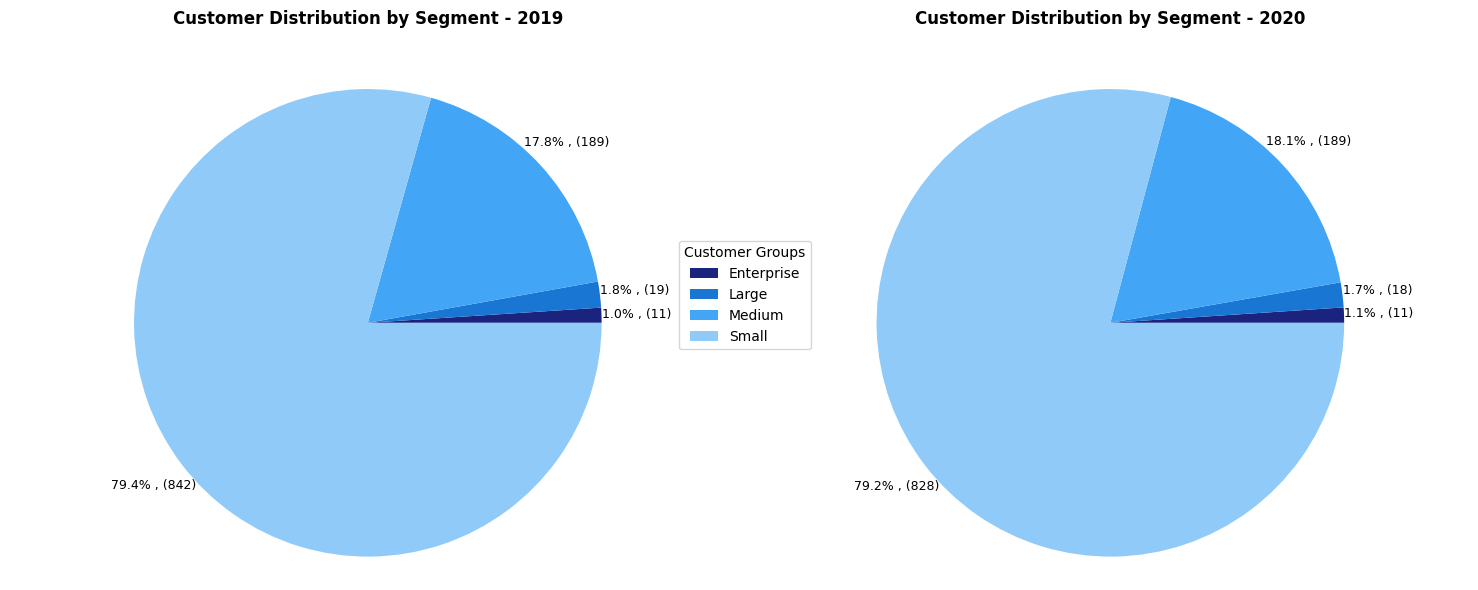

In [22]:
colors = [GROUP_COLORS[g] for g in GROUP_ORDER]

def autopct_with_counts(values):
    def inner(pct):
        total = sum(values)
        count = int(round(pct * total / 100))
        return f'{pct:.1f}% , ({count})'
    return inner

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

wedges1, _, autotexts1 = axes[0].pie(
    seg_2019,
    autopct=autopct_with_counts(seg_2019),
    colors=colors,
    radius=0.7,
    pctdistance=1.15,
    textprops={'fontsize': 9}
)
axes[0].set_title('Customer Distribution by Segment - 2019', fontweight='bold', pad=30)

wedges2, _, autotexts2 = axes[1].pie(
    seg_2020,
    autopct=autopct_with_counts(seg_2020),
    colors=colors,
    radius=0.7,
    pctdistance=1.15,
    textprops={'fontsize': 9}
)
axes[1].set_title('Customer Distribution by Segment - 2020', fontweight='bold', pad=30)

fig.legend(wedges1, GROUP_ORDER, title="Customer Groups",
           loc="center", bbox_to_anchor=(0.5, 0.5))

for ax in axes:
    ax.axis('equal')

plt.tight_layout()
plt.show()

## Segment Volume Summary Table

Parcel volumes are aggregated by customer group and year, then reshaped into a tabular format with years as columns and customer groups as rows.

This structure provides a clear side-by-side comparison of segment performance across years, making it easier to observe changes in shipment volumes for each customer group.

In [23]:
seg_df = df.groupby(['CustomerGroup', 'THE_YEAR'])['VOLUME'] \
           .sum() \
           .unstack(fill_value=0)

print("Segment Volume Totals by Year:")
display(seg_df)

Segment Volume Totals by Year:


THE_YEAR,2018,2019,2020,2021
CustomerGroup,,,,
Enterprise,35497636,37851760,53611311,35140770
Large,4631988,5340817,7032791,4789948
Medium,6654854,6939968,9408842,6410867
Small,2315000,2690569,3422746,2338083


##	**What percent of each customer group is growing, moderately growing, and declining during the COVID observation period?**

## Customer Growth Classification

Customer-level parcel volumes are calculated for three periods: full year 2019, pre-COVID 2020 (up to the defined cutoff week), and the COVID observation period in 2020.

These values are combined into a single dataset, along with the assigned customer group, to enable detailed customer-level analysis.

A growth percentage is computed by comparing COVID-period volumes with pre-COVID volumes for each customer. Based on this growth and predefined criteria, customers are classified into the following categories:

| Label                     | LOW Condition                                  | HIGH Condition                               |
|---------------------------|-----------------------------------------------|----------------------------------------------|
| New Customers             | 0 parcels in 2019 / early 2020                | 1+ parcels during COVID period               |
| High Growth Customers     | Greater than ISGR during COVID period         | No upper limit                               |
| Stable Customers          | 0% growth during COVID period                 | Up to ISGR during COVID period               |
| Declining Customers       | N/A                                           | Negative growth during COVID period          |
| Lost Customers            | 1+ parcels in 2019 / early 2020               | 0 parcels during COVID period                |

Unclassified customers are those who had no parcel activity during the pre-COVID baseline period (Weeks 1–15 of 2020), but were not strictly new customers and showed activity during the COVID period. Since no baseline exists, growth rates cannot be computed, and these customers are excluded from growth-based classification.

The resulting dataset provides a structured view of customer behavior during the pandemic. Customer statuses are further aggregated by customer group and presented in a pivot table, showing the number of customers in each category (High Growth, Stable, Declining, New, and Lost) for each group. This enables a clear comparison of how different customer segments were impacted during the COVID-19 period.

In [24]:
cust_pre_2020 = df[(df['THE_YEAR'] == 2020) & (df['THE_WEEK'] <= pre_wks)] \
    .groupby('FakeCustomerID')['VOLUME'].sum()

cust_covid_2020 = df[(df['THE_YEAR'] == 2020) & (df['THE_WEEK'] >= covid_start_week)] \
    .groupby('FakeCustomerID')['VOLUME'].sum()

cust_vol_2019 = df[df['THE_YEAR'] == 2019] \
    .groupby('FakeCustomerID')['VOLUME'].sum()

groups = df[['FakeCustomerID', 'CustomerGroup']] \
    .drop_duplicates().set_index('FakeCustomerID')

cust = pd.DataFrame({
    'Vol2019': cust_vol_2019,
    'PreVolume': cust_pre_2020,
    'CovidVolume': cust_covid_2020
}).fillna(0).join(groups)

cust['GrowthPct'] = np.where(
    cust['PreVolume'] > 0,
    ((cust['CovidVolume'] - cust['PreVolume']) / cust['PreVolume']) * 100,
    np.nan
)

def classify(row):
    if row['Vol2019'] == 0 and row['PreVolume'] == 0 and row['CovidVolume'] > 0:
        return 'New Customers'
    elif row['PreVolume'] > 0 and row['CovidVolume'] == 0:
        return 'Lost Customers'
    elif pd.isna(row['GrowthPct']):
        return 'Unclassified'
    elif row['GrowthPct'] > ISGR:
        return 'High Growth Customers'
    elif row['GrowthPct'] >= 0:
        return 'Stable Customers'
    else:
        return 'Declining Customers'

cust['Status'] = cust.apply(classify, axis=1)

status_order = [
    'High Growth Customers',
    'Stable Customers',
    'Declining Customers',
    'New Customers',
    'Lost Customers'
]

group_status_pivot = (
    cust.groupby(['CustomerGroup', 'Status'])
    .size()
    .unstack()
    .reindex(columns=status_order)
    .fillna(0)
    .astype(int)
)

group_status_pivot

Status,High Growth Customers,Stable Customers,Declining Customers,New Customers,Lost Customers
CustomerGroup,,,,,
Enterprise,11,0,0,0,0
Large,18,0,0,0,0
Medium,181,1,6,0,0
Small,768,1,41,0,12


## Customer Growth Classification During COVID

Customer counts are grouped by both **customer segment** and **growth status**, and then converted into percentages within each segment for better comparison.

The stacked analysis highlights how different customer groups (Enterprise, Large, Medium, Small) are distributed across growth categories such as high growth, stable, declining, and unclassified.

Unclassified customers are those who had no parcel activity during the pre-COVID baseline period (Weeks 1–15 of 2020), but were not strictly new customers and showed activity during the COVID period. Since no baseline exists, growth rates cannot be computed, and these customers are excluded from growth-based classification.

This visualization provides a clear breakdown of customer behavior changes during the COVID period across different business segments.

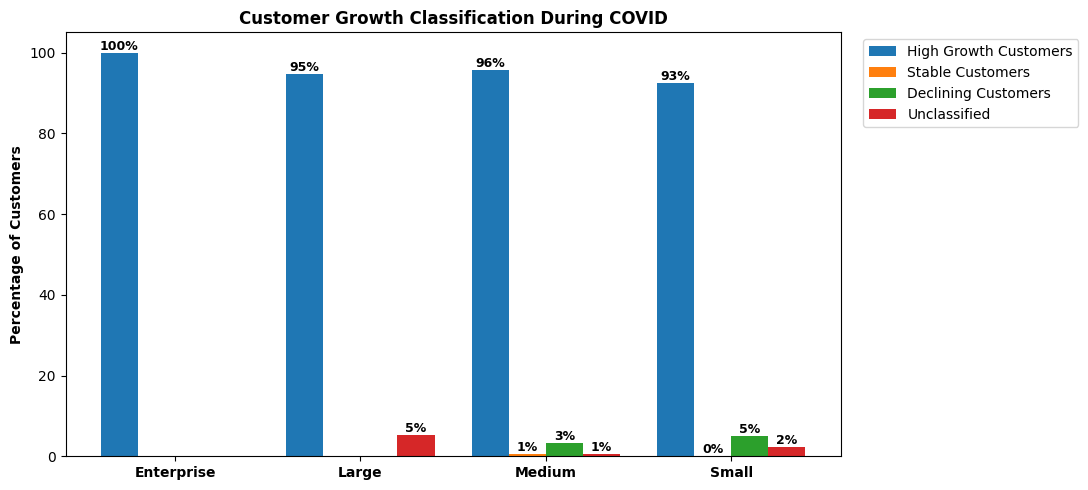

In [25]:
status1 = [
    'High Growth Customers',
    'Stable Customers',
    'Declining Customers',
    'Unclassified'
]

summary1 = (
    cust.groupby(['CustomerGroup', 'Status'])
    .size()
    .unstack(fill_value=0)
    .reindex(GROUP_ORDER)
)

summary1 = summary1.reindex(columns=status1, fill_value=0)

summary1_pct = summary1.div(summary1.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(11, 5))

x = np.arange(len(GROUP_ORDER))
width = 0.2

for i, s in enumerate(status1):
    bars = ax.bar(
        x + (i - 1.5) * width,
        summary1_pct[s],
        width,
        label=s
    )

    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(
                bar.get_x() + bar.get_width()/2,
                h,
                f'{h:.0f}%',
                ha='center',
                va='bottom',
                fontsize=9,
                fontweight='bold'
            )

ax.set_xticks(x)
ax.set_xticklabels(GROUP_ORDER, fontweight='bold')
ax.set_ylabel('Percentage of Customers', fontweight='bold')

ax.set_title(
    'Customer Growth Classification During COVID',
    fontweight='bold'
)

ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.savefig('fig_growth_status.png', dpi=150, bbox_inches='tight')
plt.show()

## **What percent of each customer group are new customers during the COVID observation period?**

## New Customer Percentage During COVID

The percentage of **new customers during the COVID period** is calculated separately for each customer group (Enterprise, Large, Medium, Small).

A customer is considered *new* if they had no recorded activity in both the 2019 period and the pre-COVID period of 2020 (Weeks 1–12), but showed parcel activity during the COVID observation period (Week 13 onwards).

This metric is then visualized using a bar chart to compare the proportion of new customer acquisition across different segments during COVID.

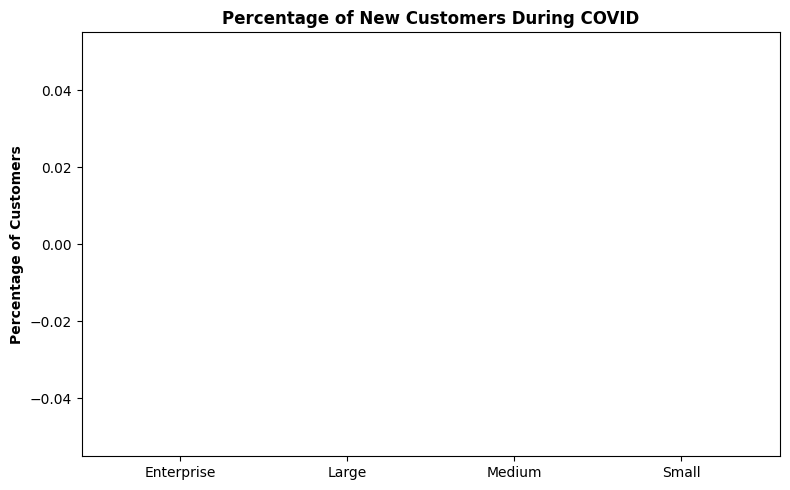

In [26]:
new_pct = []

for g in GROUP_ORDER:

    group_ids = avg_annual[avg_annual['CustomerGroup'] == g]['FakeCustomerID']

    group_data = df[df['FakeCustomerID'].isin(group_ids)]

    g_vol_2019 = group_data[group_data['THE_YEAR'] == 2019] \
        .groupby('FakeCustomerID')['VOLUME'].sum()

    g_pre_2020 = group_data[
        (group_data['THE_YEAR'] == 2020) &
        (group_data['THE_WEEK'] <= pre_wks)
    ].groupby('FakeCustomerID')['VOLUME'].sum()

    covid_vol = group_data[
        (group_data['THE_YEAR'] == 2020) &
        (group_data['THE_WEEK'] >= covid_start_week)
    ].groupby('FakeCustomerID')['VOLUME'].sum()

    ids = set(group_ids)

    new_count = sum(
        1 for cid in ids
        if (g_vol_2019.get(cid, 0) + g_pre_2020.get(cid, 0) == 0)
        and (covid_vol.get(cid, 0) > 0)
    )

    pct = (new_count / len(ids)) * 100 if len(ids) > 0 else 0
    new_pct.append(pct)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(GROUP_ORDER, new_pct)

for bar in bars:
    h = bar.get_height()
    if h > 0:
        ax.text(
            bar.get_x() + bar.get_width()/2,
            h,
            f'{h:.1f}%',
            ha='center',
            va='bottom',
            fontweight='bold'
        )

ax.set_title(
    'Percentage of New Customers During COVID',
    fontweight='bold'
)

ax.set_ylabel('Percentage of Customers', fontweight='bold')

plt.tight_layout()
plt.savefig('fig_new_customers.png', dpi=150, bbox_inches='tight')
plt.show()

##	**What percent of 2019 customers in each group did we lose during the COVID observation period?**

## Lost Customers During COVID

The percentage of **lost customers** is calculated for each customer group based on those who had parcel activity before COVID (either in 2019 or the pre-COVID period of 2020) but recorded no activity during the COVID observation period.

This percentage is computed within each segment and visualized using a bar chart, with both the percentage and the corresponding number of lost customers displayed for each group.

The analysis helps identify which customer segments experienced the highest level of customer attrition during the COVID period, while also providing context on the magnitude of customer loss.

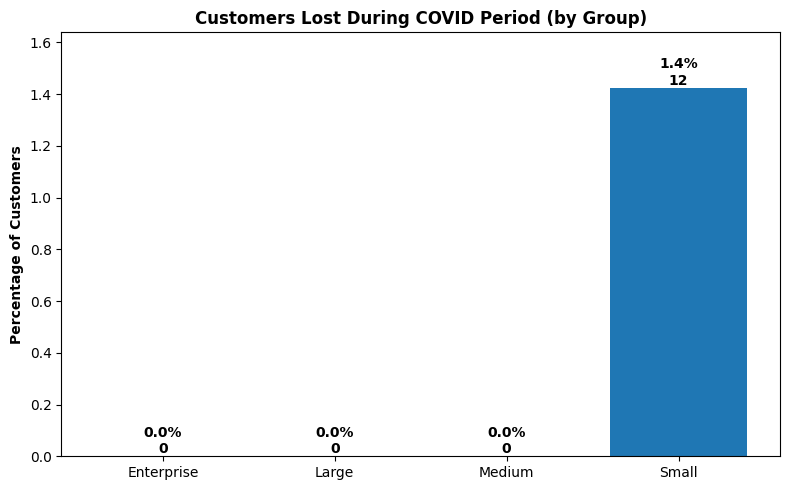

In [27]:
lost_pct = []
lost_counts = []

for g in GROUP_ORDER:
    group = cust[
        (cust['CustomerGroup'] == g) &
        ((cust['Vol2019'] > 0) | (cust['PreVolume'] > 0))
    ]

    lost = (group['Status'] == 'Lost Customers')

    pct = lost.mean() * 100
    count = lost.sum()

    lost_pct.append(pct)
    lost_counts.append(count)

fig, ax = plt.subplots(figsize=(8,5))

bars = ax.bar(GROUP_ORDER, lost_pct)

for bar, pct, count in zip(bars, lost_pct, lost_counts):
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        h,
        f'{pct:.1f}%\n{count}',
        ha='center',
        va='bottom',
        fontweight='bold'
    )

ax.set_title('Customers Lost During COVID Period (by Group)', fontweight='bold')
ax.set_ylabel('Percentage of Customers',fontweight='bold')
ax.set_ylim(0, max(lost_pct) * 1.15)
plt.tight_layout()
plt.savefig('fig_lost_customers.png', dpi=150, bbox_inches='tight')
plt.show()

##	**What was the overall impact of COVID on volumes and revenue by customer group?**

## Parcel Volume Comparison by Customer Group

A grouped bar chart is used to compare parcel volumes for 2019 and 2020 across each customer group. Volumes are presented in millions to improve readability.

Value labels are added to display the shipment totals for both years, and percentage change annotations are included above the 2020 bars to highlight growth or decline relative to 2019.

This visualization provides a clear comparison of how parcel volumes shifted across customer segments during the COVID-19 period.

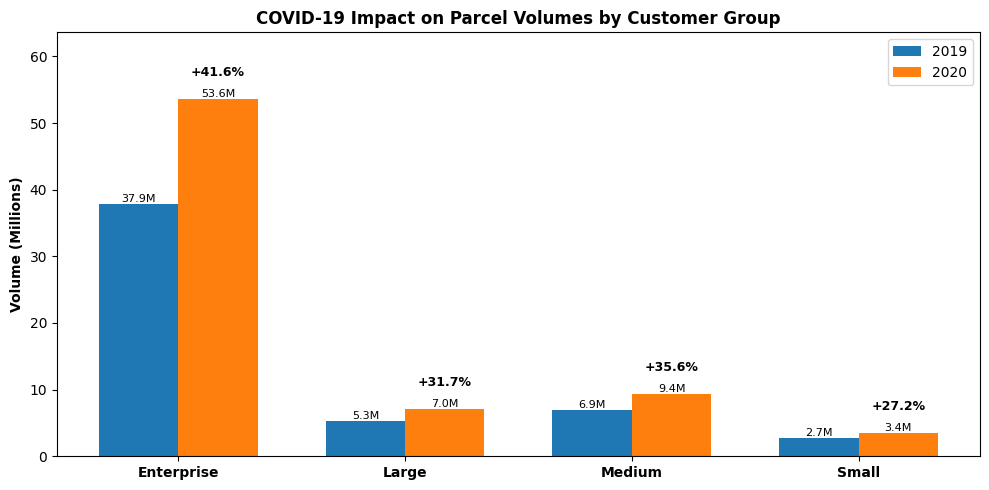

In [28]:
vol_2019 = (
    df[df['THE_YEAR'] == 2019]
    .groupby('CustomerGroup')['VOLUME']
    .sum()
    .reindex(GROUP_ORDER)
)

vol_2020 = (
    df[df['THE_YEAR'] == 2020]
    .groupby('CustomerGroup')['VOLUME']
    .sum()
    .reindex(GROUP_ORDER)
)


pct_change = ((vol_2020 - vol_2019) / vol_2019.replace(0, np.nan)) * 100

fig, ax = plt.subplots(figsize=(10,5))

x     = np.arange(len(GROUP_ORDER))
width = 0.35

bars1 = ax.bar(x - width/2, vol_2019/1e6, width, label='2019')
bars2 = ax.bar(x + width/2, vol_2020/1e6, width, label='2020')

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            h,
            f'{h:.1f}M',
            ha='center',
            va='bottom',
            fontsize=8
        )

for i, bar in enumerate(bars2):
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        h + 3,
        f'+{pct_change.iloc[i]:.1f}%',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

ax.set_xticks(x)
ax.set_xticklabels(GROUP_ORDER, fontweight='bold')
ax.set_ylabel('Volume (Millions)', fontweight='bold')
ax.set_title('COVID-19 Impact on Parcel Volumes by Customer Group', fontweight='bold')
ax.legend()

ax.set_ylim(0, max(vol_2020/1e6) + 10)

plt.tight_layout()
plt.savefig('fig_volume_by_group.png', dpi=150, bbox_inches='tight')
plt.show()

## Revenue Comparison by Customer Group

Revenue is calculated by multiplying parcel volume with the corresponding price per parcel for each customer group.

A grouped bar chart is used to compare total revenue for 2019 and 2020 across all segments, with values displayed in millions for clarity. Data labels are added to show revenue totals, and percentage change annotations highlight the growth or decline between the two years.

Chart formatting adjustments are applied to improve readability and presentation.

This visualization provides insight into how revenue performance varied across customer groups during the COVID-19 period.

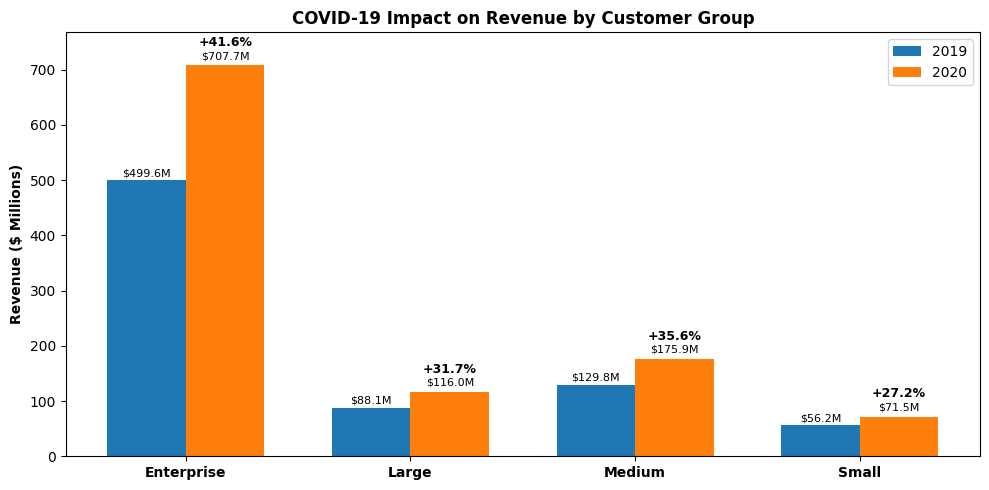

In [29]:
df['Revenue'] = df['VOLUME'] * df['CustomerGroup'].map(PRICES)

rev_2019 = (
    df[df['THE_YEAR'] == 2019]
    .groupby('CustomerGroup')['Revenue']
    .sum()
    .reindex(GROUP_ORDER)
)

rev_2020 = (
    df[df['THE_YEAR'] == 2020]
    .groupby('CustomerGroup')['Revenue']
    .sum()
    .reindex(GROUP_ORDER)
)

rev_2019_m = rev_2019 / 1e6
rev_2020_m = rev_2020 / 1e6

pct_change_rev = ((rev_2020 - rev_2019) / rev_2019.replace(0, np.nan)) * 100

fig, ax = plt.subplots(figsize=(10,5))

x     = np.arange(len(GROUP_ORDER))
width = 0.35

bars1 = ax.bar(x - width/2, rev_2019_m, width, label='2019')
bars2 = ax.bar(x + width/2, rev_2020_m, width, label='2020')

for bar in bars1:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        h + 3,
        f'${h:.1f}M',
        ha='center',
        va='bottom',
        fontsize=8
    )

for i, bar in enumerate(bars2):
    h = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width()/2,
        h + 8,
        f'${h:.1f}M',
        ha='center',
        va='bottom',
        fontsize=8
    )

    ax.text(
        bar.get_x() + bar.get_width()/2,
        h + 30,
        f'+{pct_change_rev.iloc[i]:.1f}%',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

ax.set_xticks(x)
ax.set_xticklabels(GROUP_ORDER, fontweight='bold')
ax.set_ylabel('Revenue ($ Millions)', fontweight='bold')
ax.set_title('COVID-19 Impact on Revenue by Customer Group', fontweight='bold')
ax.legend()

ax.set_ylim(0, max(rev_2020_m) + 60)

plt.tight_layout()
plt.savefig('fig_revenue_by_group.png', dpi=150, bbox_inches='tight')
plt.show()

## Key Insights Summary

- Parcel volumes in early 2020 followed a similar trend to 2019 but began to shift after the COVID-19 emergency declaration in Week 12.

- Following the start of the COVID observation period (Week 13), overall shipment volumes increased compared to 2019, indicating a rise in demand likely driven by changes in consumer behavior.

- The holiday peak season (around Week 45) experienced significantly higher volumes in 2020 than in 2019, suggesting that increased reliance on e-commerce amplified peak season demand.

- Customer impact varied across segments, with some groups experiencing strong growth while others declined, highlighting uneven effects of the pandemic across industries.

- A noticeable proportion of customers showed high growth during the COVID period, while some customers were lost, indicating both opportunity and risk within the customer base.

- Overall, COVID-19 had a positive impact on parcel volumes, but growth was not uniform across all customer groups, emphasizing the importance of targeted business strategies.

## Recommendations

Based on the analysis of parcel volumes, customer segmentation, growth classification, and revenue impact during the COVID-19 period, the following recommendations are proposed:

**1. Strengthen High Growth Segments**  
Customer groups that experienced growth above the ISGR should be prioritized. These customers have demonstrated strong demand during disruption and present opportunities for long-term revenue expansion. Targeted retention strategies, customized pricing, and service enhancements can help sustain this growth.

**2. Retain and Support Stable Customers**  
Stable customers represent a consistent revenue base. Maintaining service reliability, offering loyalty incentives, and monitoring their activity can prevent them from shifting into declining or lost categories.

**3. Address Declining and Lost Customers**  
Customers showing negative growth or no activity during COVID should be analyzed further to identify underlying causes such as operational challenges, industry-specific downturns, or competitive shifts. Re-engagement strategies such as targeted promotions or flexible pricing can help recover these accounts.

**4. Focus on New Customer Acquisition**  
No new customers were acquired during the COVID period, highlighting a missed growth opportunity. Strengthening onboarding processes and targeting similar customer profiles can help expand the customer base and drive future growth.

**5. Optimize Pricing and Discount Strategy**  
Since revenue impact varies across customer groups due to different discount levels, pricing strategies should be reviewed to ensure profitability while remaining competitive. High-volume customers may benefit from optimized discount structures tied to performance or long-term contracts.

**6. Enhance Peak Season Preparedness**  
Given the observed changes in peak season demand, operational capacity, logistics planning, and workforce allocation should be adjusted to handle potential surges more efficiently in future high-demand periods.

**7. Monitor Customer Behavior Continuously**  
Implement ongoing tracking of customer growth patterns using ISGR-based classification. This enables early identification of shifting trends and supports proactive decision-making.

## Conclusion

The analysis shows that the COVID-19 pandemic had a significant and largely positive impact on ABC Company’s parcel delivery business, driving overall growth in shipment volumes.

However, this impact was not uniform across all customers. While some customer segments experienced strong growth due to increased reliance on delivery services and e-commerce, others showed declining activity or were lost during the COVID period. These differences highlight the uneven effect of the pandemic across the customer base.

Changes in peak season trends further indicate a shift in demand patterns, suggesting that customer behavior during the pandemic differed from traditional seasonal expectations.

Customer segmentation and growth classification provided deeper insight into these behavioral shifts, enabling identification of high-growth, stable, declining, new, and lost customers. This segmentation is critical for understanding which customer groups contributed most to overall performance.

Revenue analysis confirms that fluctuations in parcel volumes, along with pricing and discount structures, directly influenced financial outcomes across customer segments.

Overall, the pandemic acted as a catalyst for increased parcel demand, primarily driven by the rapid growth of e-commerce. These insights emphasize the importance of targeted customer strategies, pricing optimization, and data-driven decision-making to sustain growth and improve resilience in future disruptions.